In [1]:
import os
os.chdir('..')

In [2]:
import pm4py
import pickle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pm4py.algo.analysis.woflan import algorithm as woflan

------ Iteration 0 ------


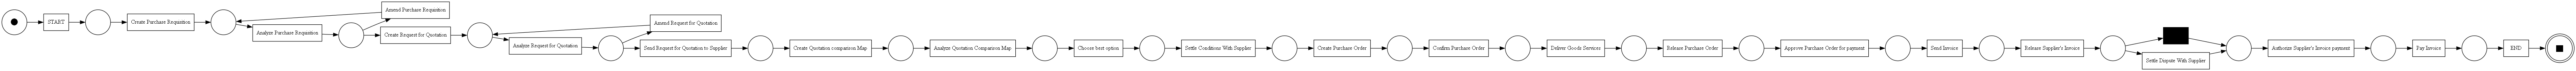

Net is sound.



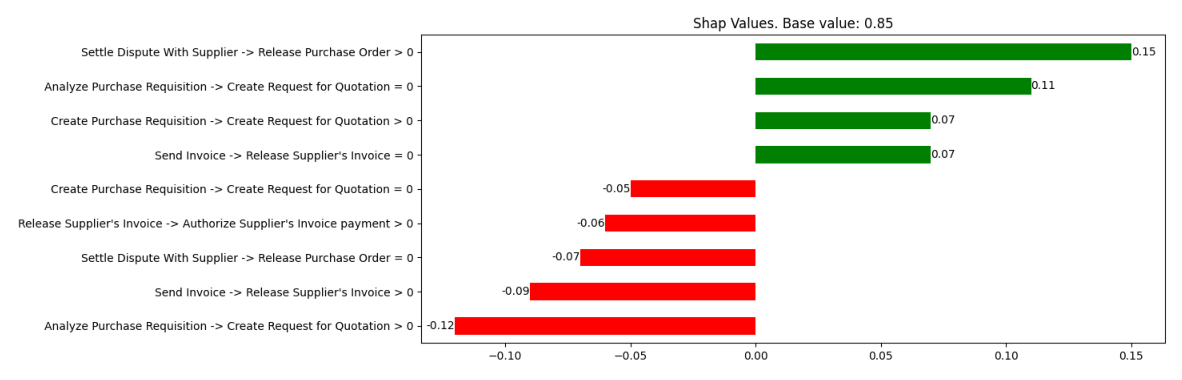

Analyze Purchase Requisition -> Create Request for Quotation :  skip_b
Settle Dispute With Supplier -> Release Purchase Order :  skip
Release Purchase Order -> Settle Dispute With Supplier :  skip
Send Invoice -> Release Supplier's Invoice :  skip_b
Release Supplier's Invoice -> Authorize Supplier's Invoice payment :  skip_b
Create Purchase Requisition -> Create Request for Quotation :  skip
Create Purchase Requisition -> Analyze Purchase Requisition :  skip_b



------ Iteration 1 ------


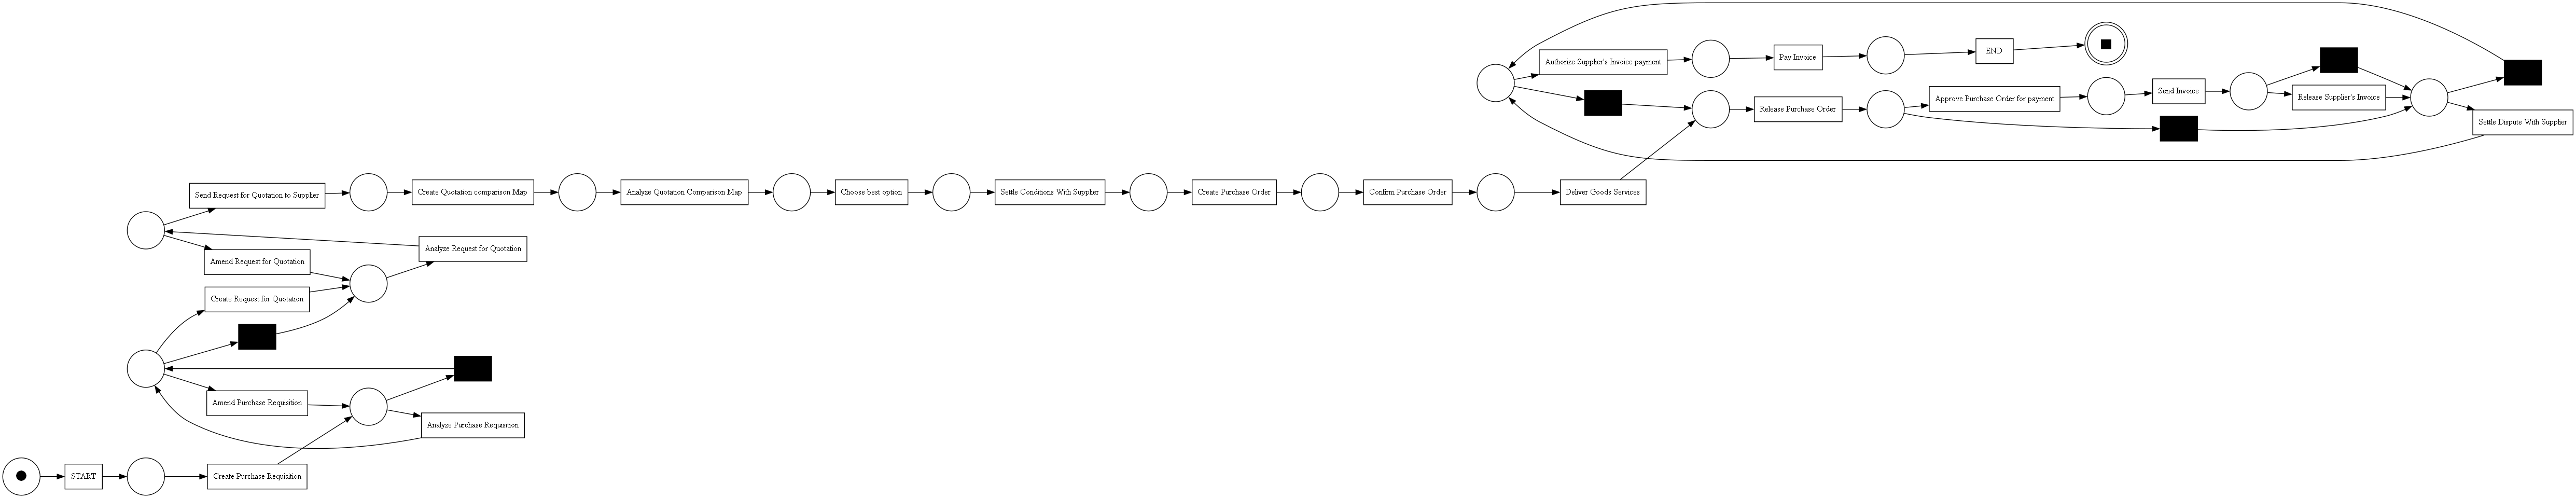

Net is sound.



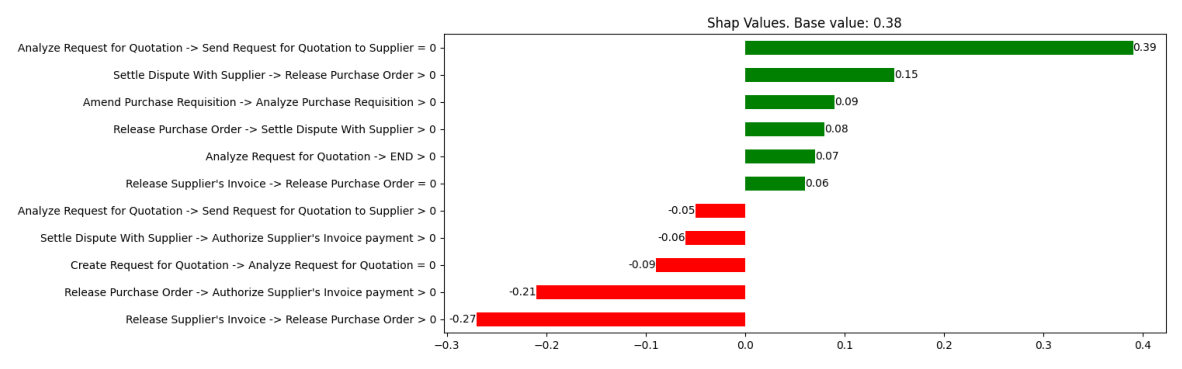

Release Purchase Order -> Authorize Supplier's Invoice payment :  skip_b
Settle Dispute With Supplier -> Release Purchase Order :  skip
Create Request for Quotation -> Analyze Request for Quotation :  skip
Amend Purchase Requisition -> Analyze Purchase Requisition :  skip
Release Purchase Order -> Settle Dispute With Supplier :  skip
Analyze Request for Quotation -> END :  skip
Release Supplier's Invoice -> Release Purchase Order :  skip_b
Settle Dispute With Supplier -> Authorize Supplier's Invoice payment :  skip_b



------ Iteration 2 ------


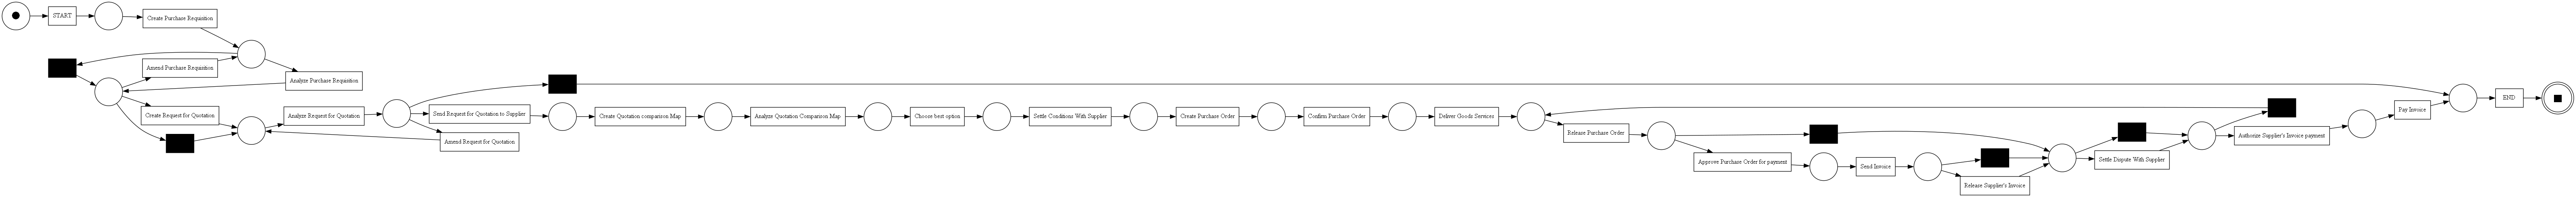

Net is sound.



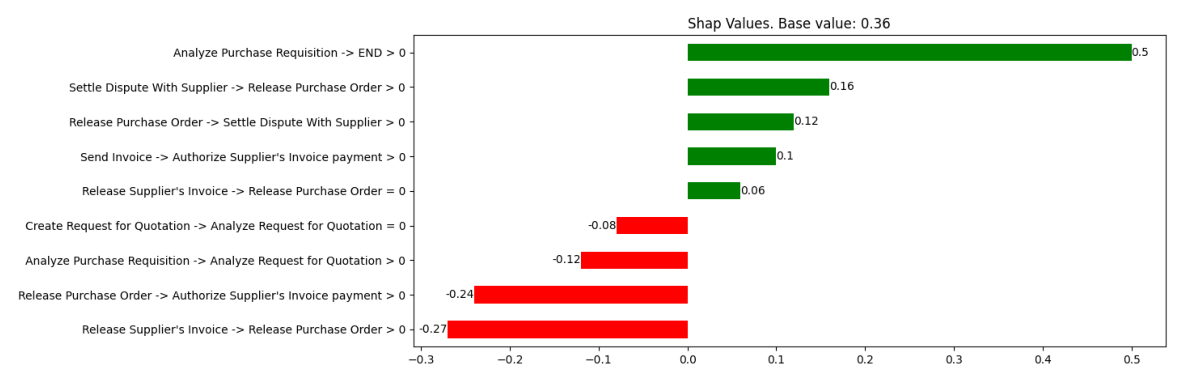

Analyze Purchase Requisition -> END :  skip
Release Purchase Order -> Authorize Supplier's Invoice payment :  skip_b
Settle Dispute With Supplier -> Release Purchase Order :  skip
Release Purchase Order -> Settle Dispute With Supplier :  skip
Analyze Purchase Requisition -> Analyze Request for Quotation :  skip_b
Send Invoice -> Authorize Supplier's Invoice payment :  skip
Create Request for Quotation -> Analyze Request for Quotation :  skip
Release Supplier's Invoice -> Release Purchase Order :  skip_b



------ Iteration 3 ------


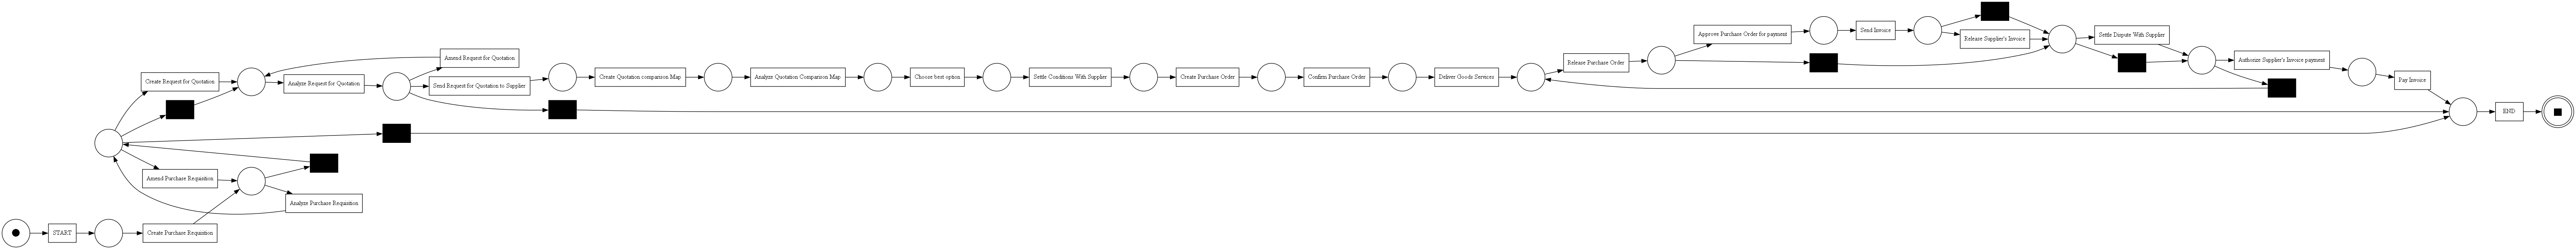

Net is sound.



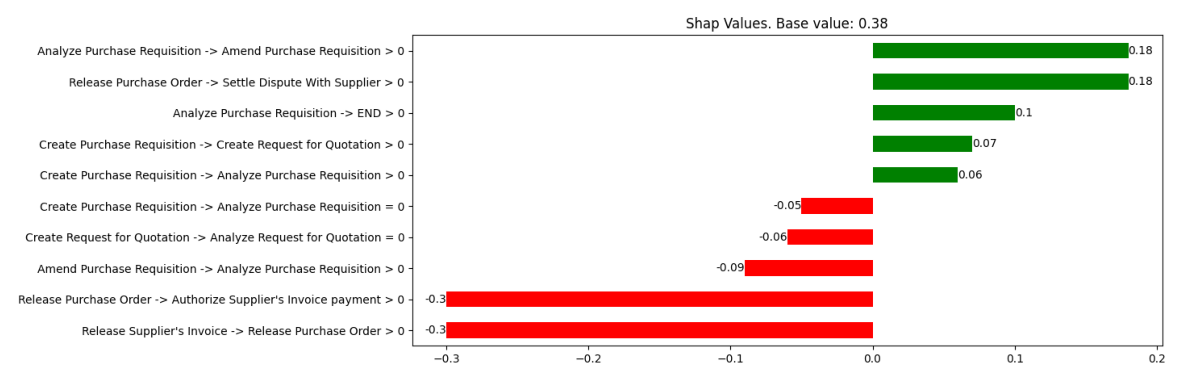

Release Supplier's Invoice -> Release Purchase Order :  skip_b
Release Purchase Order -> Authorize Supplier's Invoice payment :  skip_b
Release Purchase Order -> Settle Dispute With Supplier :  skip
Analyze Purchase Requisition -> Amend Purchase Requisition :  skip
Analyze Purchase Requisition -> END :  skip
Amend Purchase Requisition -> Analyze Purchase Requisition :  skip_b
Create Purchase Requisition -> Create Request for Quotation :  skip
Create Request for Quotation -> Analyze Request for Quotation :  skip
Create Purchase Requisition -> Analyze Purchase Requisition :  skip





In [3]:
case_study = 'Purchasing'
n_exp = 1

n_it = len(os.listdir(f'data/{case_study}/exp_{n_exp}')) - 2

for i in range(n_it):
    print(f'------ Iteration {i} ------')
    net, im, fm = pm4py.read_pnml(f'data/{case_study}/exp_{n_exp}/it_{i}/diagram_{i}.pnml')
    pm4py.view_petri_net(net, im, fm)
    is_sound = woflan.apply(net, im, fm, parameters={woflan.Parameters.RETURN_ASAP_WHEN_NOT_SOUND: True,
                                                     woflan.Parameters.PRINT_DIAGNOSTICS: False,
                                                     woflan.Parameters.RETURN_DIAGNOSTICS: False})
    if is_sound:
        print('Net is sound.\n')
    else:
        print('Net is not sound.\n')

    # ts = reachability_graph.construct_reachability_graph(net, im)
    # gviz = ts_visualizer.apply(ts)
    # ts_visualizer.view(gviz)

    plt.figure(figsize=(15, 12))
    shap_plot_img = mpimg.imread(f'plots/{case_study}/exp_{n_exp}/shap_{i}.png')
    plt.imshow(shap_plot_img)
    plt.axis('off')
    plt.show()

    file = open(f'data/{case_study}/exp_{n_exp}/it_{i}/recc_{i}.pickle', 'rb')
    recc = pickle.load(file)
    file.close()
    for r in recc:
        print(r, ': ', recc[r][1])

    print('\n'*2)
    